<a href="https://colab.research.google.com/github/neha6765venkatesh/Data-cleaning-and-preprocessing/blob/main/Task_1_Data_cleaning_and_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib
import numpy as np
import seaborn as sns


In [3]:
df=pd.read_csv('/content/Online Sales Data.csv')

In [4]:
df.head()

,Transaction ID,Date,Product Category,Product Name,Units Sold,Unit Price,Total Revenue,Region,Payment Method
0,10001,2024-01-01,Electronics,iPhone 14 Pro,2,999.99,1999.98,North America,Credit Card
1,10002,2024-01-02,Home Appliances,Dyson V11 Vacuum,1,499.99,499.99,Europe,PayPal
2,10003,2024-01-03,Clothing,Levi's 501 Jeans,3,69.99,209.97,Asia,Debit Card
3,10004,2024-01-04,Books,The Da Vinci Code,4,15.99,63.96,North America,Credit Card
4,10005,2024-01-05,Beauty Products,Neutrogena Skincare Set,1,89.99,89.99,Europe,PayPal


In [7]:
print("\nMissing values:\n", df.isnull().sum())



Missing values:
 Transaction ID      0
Date                0
Product Category    0
Product Name        0
Units Sold          0
Unit Price          0
Total Revenue       0
Region              0
Payment Method      0
dtype: int64


In [8]:
#  Handle missing values using mean/median/imputation
# Separate numerical and categorical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns


In [10]:
from sklearn.impute import SimpleImputer

In [11]:
# Impute numerical columns with mean
num_imputer = SimpleImputer(strategy='mean')
df[num_cols] = num_imputer.fit_transform(df[num_cols])

In [12]:
# Impute categorical columns with most frequent
cat_imputer = SimpleImputer(strategy='most_frequent')
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])


In [14]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [15]:
#  Convert categorical features into numerical using encoding
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [16]:
#  Normalize/standardize the numerical features
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

In [18]:
import matplotlib.pyplot as plt

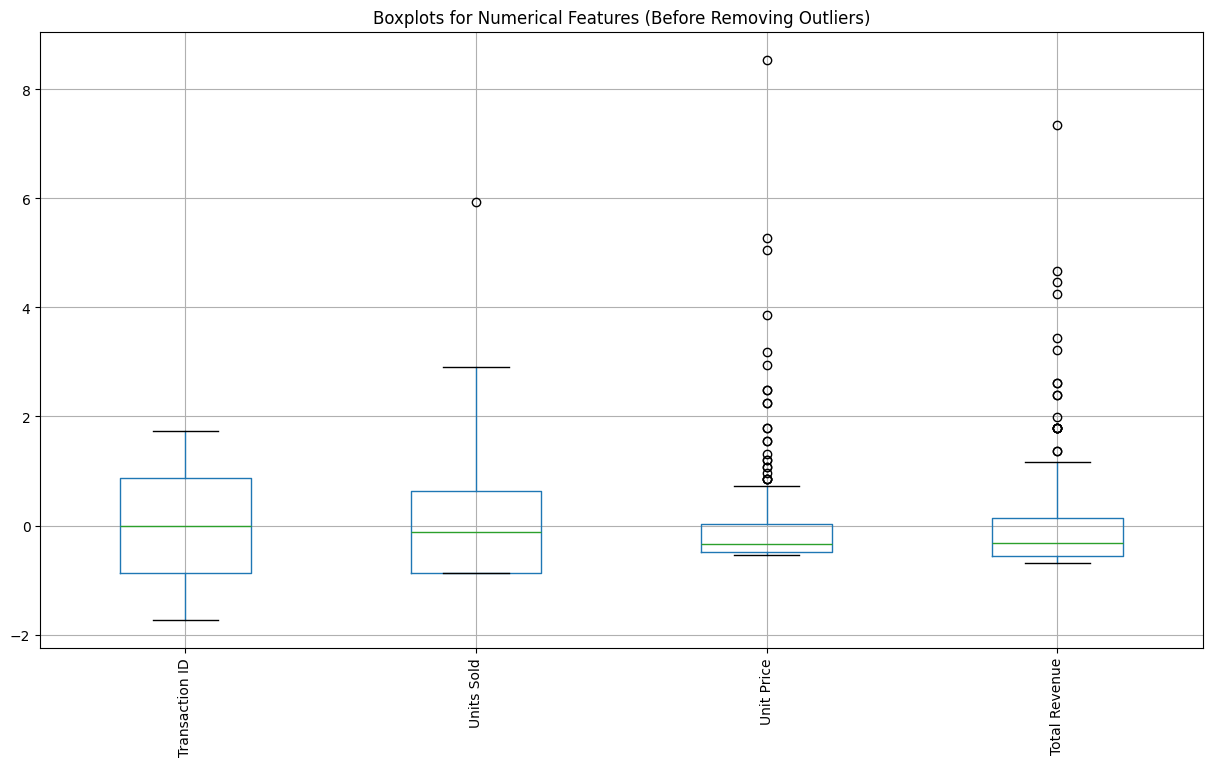

In [19]:
#  Visualize outliers using boxplots and remove them
plt.figure(figsize=(15, 8))
df[num_cols].boxplot(rot=90)
plt.title("Boxplots for Numerical Features (Before Removing Outliers)")
plt.show()

In [20]:
# Function to remove outliers using IQR
def remove_outliers(df, cols):
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df = df[(df[col] >= lower) & (df[col] <= upper)]
    return df

df_cleaned = remove_outliers(df, num_cols)

print("\nShape after removing outliers:", df_cleaned.shape)


Shape after removing outliers: (206, 9)
